In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

import torch as ch
from torch import sigmoid as sig
from torch.distributions import MultivariateNormal
import matplotlib.pyplot as plt
%matplotlib notebook
import numpy as np
from sklearn.linear_model import LogisticRegression

from delphi.utils.helpers import logistic
from torch.distributions.gumbel import Gumbel
from delphi.grad import TruncatedBCE, TruncatedCE
from delphi.stats.softmax import SoftmaxRegression

In [2]:
gumbel = Gumbel(0, 1)

In [3]:
class TruncatedCE_contained(ch.autograd.Function):
    @staticmethod
    def forward(ctx, pred, targ, phi, num_samples=5000, eps=1e-5):
        """
        Args: 
            pred (torch.Tensor): size (batch_size, 1) matrix for regression model predictions
            targ (torch.Tensor): size (batch_size, 1) matrix for regression target predictions
            phi (oracle.oracle): dependent variable membership oracle
            num_samples (int): number of samples to generate per sample in batch in rejection sampling procedure
            eps (float): denominator error constant to avoid divide by zero errors
        """  
        stacked = pred[None, ...].repeat(num_samples, 1, 1)
        rand_noise = gumbel.sample(stacked.size())
        noised = stacked + rand_noise
        noised_labs = noised.argmax(-1, keepdim=True)
        filtered = phi(noised)
        mask = (noised_labs).eq(targ)
        filtered = filtered.float()
        ctx.save_for_backward(mask, filtered, rand_noise, pred)
        ctx.eps = eps
        prob_est = (mask * filtered + eps).sum(0) / (filtered.sum(0) + eps)
        return -ch.log(prob_est) / pred.size(0)
        
    @staticmethod
    def backward(ctx, grad_output):  
        mask, filtered, rand_noise, pred = ctx.saved_tensors
        inner_exp = (1 - ch.exp(-rand_noise))
        nll = ((inner_exp * mask * filtered).sum(0) / ((mask * filtered).sum(0) + ctx.eps))
        const = ((inner_exp * filtered).sum(0) / (filtered.sum(0) + ctx.eps))
        return (-nll + const) / pred.size(0), None, None, None, None

In [4]:
class TruncatedBCE(ch.autograd.Function):
    """
    Truncated binary cross entropy gradient for truncated binary classification tasks. 
    """
    @staticmethod
    def forward(ctx, pred, targ, phi, num_samples=1000, eps=1e-5):
        """
        Args: 
            pred (torch.Tensor): size (batch_size, 1) matrix for regression model predictions
            targ (torch.Tensor): size (batch_size, 1) matrix for regression target predictions
            phi (oracle.oracle): dependent variable membership oracle
            num_samples (int): number of samples to generate per sample in batch in rejection sampling procedure
            eps (float): denominator error constant to avoid divide by zero errors
        """  
        stacked = pred[None, ...].repeat(num_samples, 1, 1)
        rand_noise = logistic.sample(stacked.size())
        # add noise
        noised = stacked + rand_noise
        noised_labs = noised >= 0
        # filter
        filtered = phi(noised)
        mask = (noised_labs).eq(targ)
        filtered = filtered.float()
        ctx.save_for_backward(mask, filtered, rand_noise)
        ctx.eps = eps
        prob_est = (mask * filtered + eps).sum(0) / (filtered.sum(0) + ctx.eps)
        return -ch.log(prob_est) / pred.size(0)

    @staticmethod
    def backward(ctx, grad_output):
        mask, filtered, rand_noise = ctx.saved_tensors

        avg = 2*(sig(rand_noise) * mask * filtered).sum(0) / ((mask * filtered).sum(0) + ctx.eps) 
        norm_const = (2 * sig(rand_noise) * filtered).sum(0) / (filtered.sum(0) + ctx.eps)
        return -(avg - norm_const) / rand_noise.size(1), None, None, None, None

In [5]:
from torch.nn import CrossEntropyLoss

ce_loss = CrossEntropyLoss()

In [6]:
def trunc_logistic_mle(pred, targ, phi, seed=69): 
    if seed is not None:
        ch.manual_seed(seed)
    loss = TruncatedBCE.apply(pred, targ, phi)
    loss = loss.sum(0)
    loss.backward()
    return loss, pred.grad

def trunc_gumbel_mle(pred, targ, phi, seed=69, loss_fn=TruncatedCE): 
    if seed is not None:
        ch.manual_seed(seed)
    loss = loss_fn.apply(pred, targ, phi, 1000)
    loss = loss.sum(0)[...,None]
    loss.backward()
    return loss, pred.grad

# Untruncated Multinomial Logistic Regression

In [7]:
from sklearn.linear_model import LogisticRegression

D, K = 1, 2

W = ch.ones(K, D)

print(f'groud truth W:\n {W}')

G = Gumbel(0, 1)

NUM_SAMPLES = 5000
X = ch.rand(NUM_SAMPLES, D)
print(f'ground truth num samples: {X.size(0)}')

Z = X @ W.T + G.sample([NUM_SAMPLES, K])

Y = Z.argmax(-1)

log_reg = LogisticRegression(penalty=None, fit_intercept=False)
log_reg.fit(X, Y)

gt_w = ch.from_numpy(log_reg.coef_)

print(f'fitted w: {gt_w}')

groud truth W:
 tensor([[1.],
        [1.]])
ground truth num samples: 5000
fitted w: tensor([[0.0376]], dtype=torch.float64)


In [8]:
def phi(z): 
    z_diff = (z[...,0] - z[...,1])[...,None]
    return ch.ones_like(z_diff)

def phi_bce(z): 
    return ch.ones_like(z)

In [9]:
trunc_indices = phi(Z).flatten().nonzero().flatten()
X_trunc, Z_trunc = X[trunc_indices], Z[trunc_indices]
Y_trunc = Y[trunc_indices]
alpha = X_trunc.size(0) / X.size(0)
print(f'alpha: {alpha}')

trunc_log_reg = LogisticRegression(penalty=None,fit_intercept=False)
trunc_log_reg.fit(X_trunc, Y_trunc)

trunc_w = ch.from_numpy(trunc_log_reg.coef_)

print(f'trunc fitted w: {trunc_w}')

alpha: 1.0
trunc fitted w: tensor([[0.0376]], dtype=torch.float64)


<IPython.core.display.Javascript object>


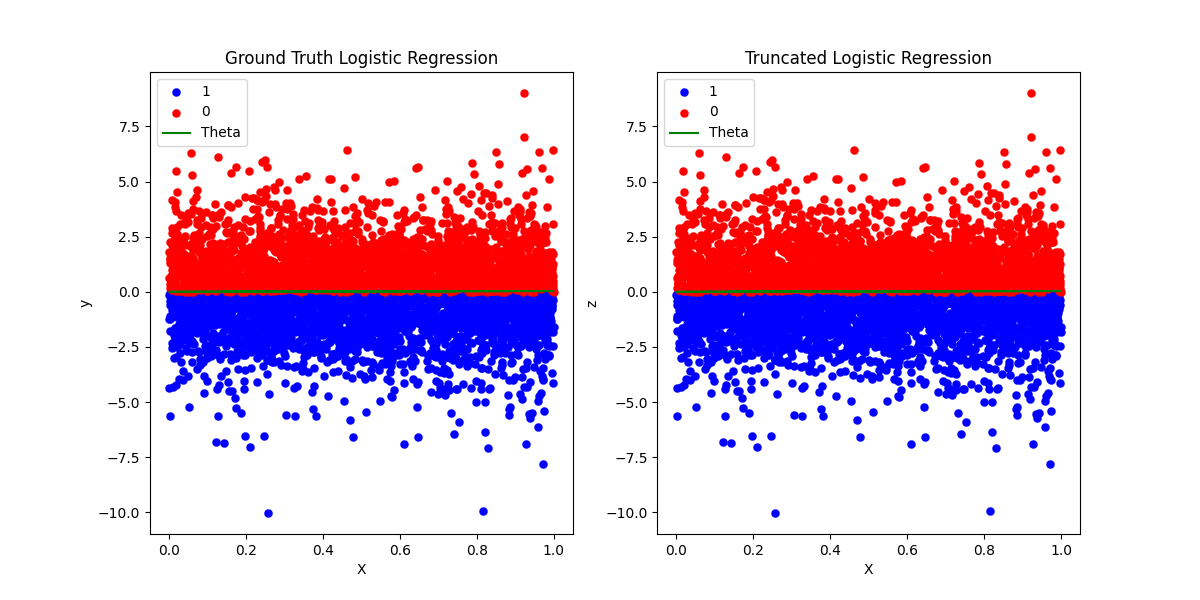

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ones = Y.flatten().nonzero().flatten()
zeros = (~Y.bool().flatten()).nonzero().flatten()

Z_zeros = Z[zeros]
Z_ones = Z[ones]

Z_zero_diff = Z_zeros[:,0] - Z_zeros[:,1]
Z_one_diff = Z_ones[:,0] - Z_ones[:,1]

ax1.scatter(X[ones], Z_one_diff, linewidths=.1, color='blue', label='1')
ax1.scatter(X[zeros], Z_zero_diff, linewidths=.1, color='red', label='0')
X_sorted = X.sort()[0]
pred = X_sorted@ch.from_numpy(log_reg.coef_).float()
ax1.plot(X_sorted, pred, color='green', label='Theta')
ax1.set_xlabel('X')
ax1.set_ylabel('y')
ax1.set_title('Ground Truth Logistic Regression')
ax1.legend()

trunc_ones = Y_trunc.flatten().nonzero().flatten()
trunc_zeros = (~Y_trunc.bool().flatten()).nonzero().flatten()

Z_trunc_ones = Z_trunc[trunc_ones]
Z_trunc_zeros = Z_trunc[trunc_zeros]

Z_trunc_zero_diff = Z_trunc_zeros[:,0] - Z_trunc_zeros[:,1]
Z_trunc_one_diff = Z_trunc_ones[:,0] - Z_trunc_ones[:,1] 

ax2.scatter(X_trunc[trunc_ones], Z_trunc_one_diff, linewidths=.1, color='blue', label='1')
ax2.scatter(X_trunc[trunc_zeros], Z_trunc_zero_diff, linewidths=.1, color='red', label='0')
trunc_pred = X_sorted@ch.from_numpy(trunc_log_reg.coef_).float()
ax2.plot(X_sorted, trunc_pred, color='green', label='Theta')
ax2.set_xlabel('X')
ax2.set_ylabel('z')
ax2.set_title('Truncated Logistic Regression')
ax2.legend()
plt.show()

In [11]:
from torch.nn import BCEWithLogitsLoss

In [12]:
bce = BCEWithLogitsLoss()


ws = ch.linspace(-3, 5, 10)

losses = ch.Tensor([])
grads = ch.Tensor([])

trunc_bce_losses = ch.Tensor([])
trunc_bce_grads = ch.Tensor([])

bce_losses = ch.Tensor([])
bce_grads = ch.Tensor([])

ce_losses = ch.Tensor([])
ce_grads = ch.Tensor([])

for w in ws: 
    for w_ in ws:
        W_ = ch.cat([w[...,None], w_[...,None]])[None,...]
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_bce = bce(pred[:,1] - pred[:,0], Y_trunc.float())
        loss_bce.backward()
        bce_losses = ch.cat([bce_losses, loss_bce[...,None].detach()])
        bce_grads = ch.cat([bce_grads, X_trunc.T@pred.grad])
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_trunc_bce, pred_grad = trunc_logistic_mle((pred[:,1] - pred[:,0])[...,None], Y_trunc.float()[...,None], phi_bce)
        trunc_bce_losses = ch.cat([trunc_bce_losses, loss_trunc_bce[...,None].detach()])
        trunc_bce_grads = ch.cat([trunc_bce_grads, X_trunc.T@pred.grad])
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_ce = ce_loss(pred, Y_trunc.long())
        loss_ce.backward()
        ce_losses = ch.cat([ce_losses, loss_ce[...,None].detach()])
        ce_grads = ch.cat([ce_grads, X_trunc.T@pred.grad])
        
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss, pred_grad = trunc_gumbel_mle(pred, Y_trunc[...,None], phi)
        losses = ch.cat([losses, loss[...,None].detach()])
        grads = ch.cat([grads, X_trunc.T@pred_grad])

/tmp/ipykernel_34673/2544813244.py:7: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  return loss, pred.grad


In [13]:
losses = losses.flatten()

<IPython.core.display.Javascript object>


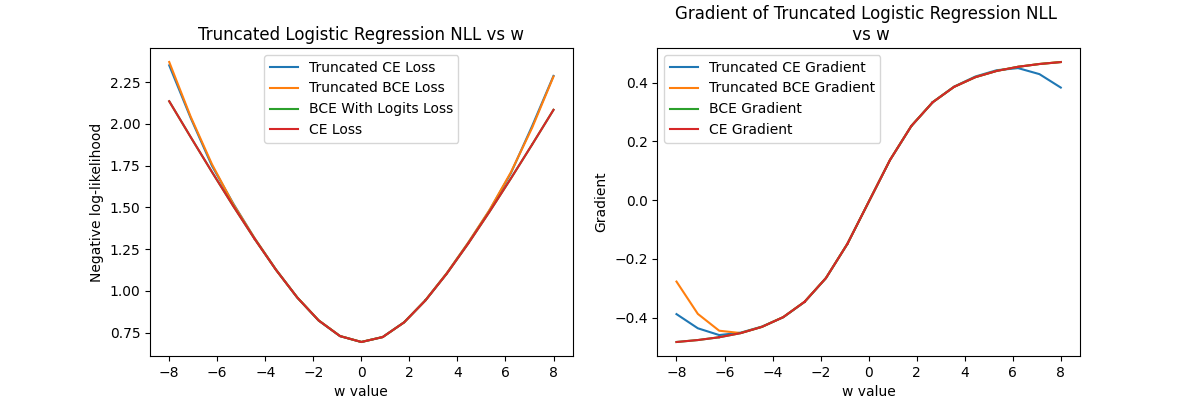

In [14]:
WS_ = ch.Tensor([])

for w_ in ws: 
    for w__ in ws: 
        WS_ = ch.cat([WS_, ch.cat([w_[...,None], w__[...,None]])[None,...]])

w_diffs = WS_[:,1] - WS_[:,0]

w_sorted, indices = w_diffs.sort()

# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(w_sorted, losses[indices], label="Truncated CE Loss")
ax1.plot(w_sorted, trunc_bce_losses[indices], label="Truncated BCE Loss")
ax1.plot(w_sorted, bce_losses[indices], label="BCE With Logits Loss")
ax1.plot(w_sorted, ce_losses[indices], label="CE Loss")

ax1.set_xlabel("w value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Logistic Regression NLL vs w")
ax1.legend()

ax2.plot(w_sorted, grads[:,1][indices] - grads[:,0][indices], label="Truncated CE Gradient")
ax2.plot(w_sorted, trunc_bce_grads[:,1][indices] - trunc_bce_grads[:,0][indices], label="Truncated BCE Gradient")
ax2.plot(w_sorted, bce_grads[:,1][indices] - bce_grads[:,0][indices], label="BCE Gradient")
ax2.plot(w_sorted, ce_grads[:,1][indices] - ce_grads[:,0][indices], label="CE Gradient")


ax2.set_xlabel("w value")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Logistic Regression NLL \n vs w")
ax2.legend()

plt.show()

#  Truncated Multinomial Logistic Regression

In [15]:
from sklearn.linear_model import LogisticRegression

D, K = 1, 2

W = ch.ones(K, D)

print(f'groud truth W:\n {W}')

G = Gumbel(0, 1)

NUM_SAMPLES = 5000
X = ch.rand(NUM_SAMPLES, D)
print(f'ground truth num samples: {X.size(0)}')

Z = X @ W.T + G.sample([NUM_SAMPLES, K])

Y = Z.argmax(-1)

log_reg = LogisticRegression(penalty=None, fit_intercept=False)
log_reg.fit(X, Y)

gt_w = ch.from_numpy(log_reg.coef_)

print(f'fitted w: {gt_w}')

groud truth W:
 tensor([[1.],
        [1.]])
ground truth num samples: 5000
fitted w: tensor([[0.0358]], dtype=torch.float64)


In [16]:
def phi(z): 
    z_diff = (z[...,1] - z[...,0])[...,None]
    return z_diff > -.25

def phi_bce(z): 
    return z > -.25

In [17]:
trunc_indices = phi(Z).flatten().nonzero().flatten()
X_trunc, Z_trunc = X[trunc_indices], Z[trunc_indices]
Y_trunc = Y[trunc_indices]
alpha = X_trunc.size(0) / X.size(0)
print(f'alpha: {alpha}')

trunc_log_reg = LogisticRegression(penalty=None,fit_intercept=False)
trunc_log_reg.fit(X_trunc, Y_trunc)

trunc_w = ch.from_numpy(trunc_log_reg.coef_)

print(f'trunc fitted w: {trunc_w}')

alpha: 0.5594
trunc fitted w: tensor([[3.8479]], dtype=torch.float64)


<IPython.core.display.Javascript object>


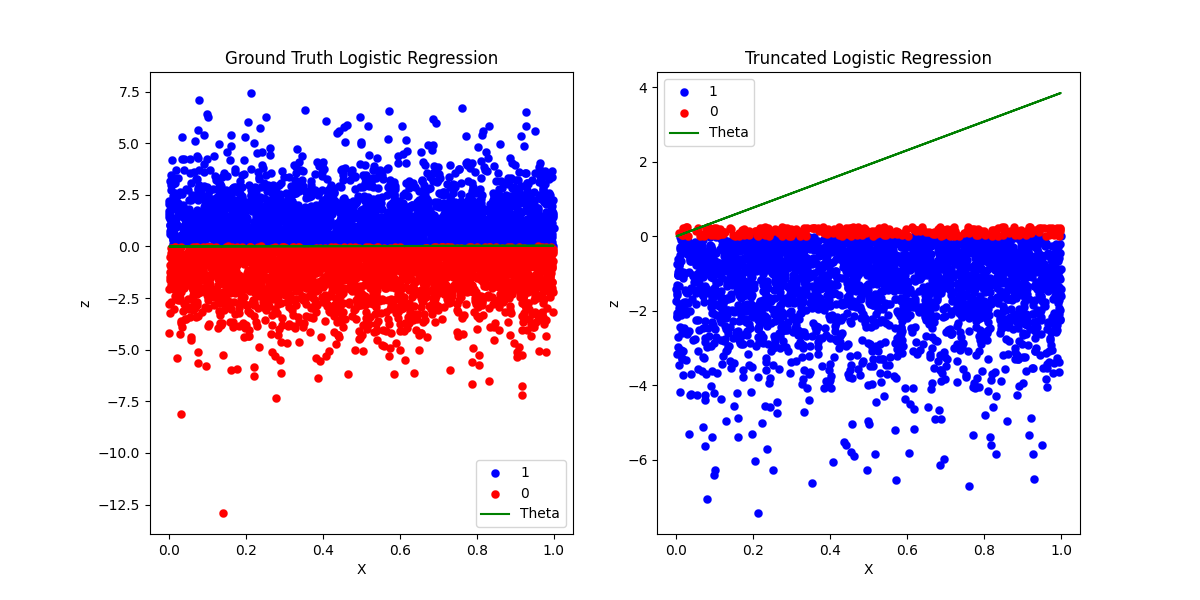

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ones = Y.flatten().nonzero().flatten()
zeros = (~Y.bool().flatten()).nonzero().flatten()

Z_zeros = Z[zeros]
Z_ones = Z[ones]

Z_zero_diff = Z_zeros[:,1] - Z_zeros[:,0]
Z_one_diff = Z_ones[:,1] - Z_ones[:,0]

ax1.scatter(X[ones], Z_one_diff, linewidths=.1, color='blue', label='1')
ax1.scatter(X[zeros], Z_zero_diff, linewidths=.1, color='red', label='0')
X_sorted = X.sort()[0]
pred = X_sorted@ch.from_numpy(log_reg.coef_).float()
ax1.plot(X_sorted, pred, color='green', label='Theta')
ax1.set_xlabel('X')
ax1.set_ylabel('z')
ax1.set_title('Ground Truth Logistic Regression')
ax1.legend()

trunc_ones = Y_trunc.flatten().nonzero().flatten()
trunc_zeros = (~Y_trunc.bool().flatten()).nonzero().flatten()

Z_trunc_ones = Z_trunc[trunc_ones]
Z_trunc_zeros = Z_trunc[trunc_zeros]

Z_trunc_zero_diff = Z_trunc_zeros[:,0] - Z_trunc_zeros[:,1]
Z_trunc_one_diff = Z_trunc_ones[:,0] - Z_trunc_ones[:,1] 

ax2.scatter(X_trunc[trunc_ones], Z_trunc_one_diff, linewidths=.1, color='blue', label='1')
ax2.scatter(X_trunc[trunc_zeros], Z_trunc_zero_diff, linewidths=.1, color='red', label='0')
trunc_pred = X_sorted@ch.from_numpy(trunc_log_reg.coef_).float()
ax2.plot(X_sorted, trunc_pred, color='green', label='Theta')
ax2.set_xlabel('X')
ax2.set_ylabel('z')
ax2.set_title('Truncated Logistic Regression')
ax2.legend()
plt.show()

In [19]:
bce = BCEWithLogitsLoss()

ws = ch.linspace(-3, 5, 10)

losses = ch.Tensor([])
grads = ch.Tensor([])

trunc_bce_losses = ch.Tensor([])
trunc_bce_grads = ch.Tensor([])

bce_losses = ch.Tensor([])
bce_grads = ch.Tensor([])

ce_losses = ch.Tensor([])
ce_grads = ch.Tensor([])

for w in ws: 
    for w_ in ws:
        W_ = ch.cat([w[...,None], w_[...,None]])[None,...]
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_bce = bce(pred[:,1] - pred[:,0], Y_trunc.float())
        loss_bce.backward()
        bce_losses = ch.cat([bce_losses, loss_bce[...,None].detach()])
        bce_grads = ch.cat([bce_grads, X_trunc.T@pred.grad])
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_trunc_bce, pred_grad = trunc_logistic_mle((pred[:,1] - pred[:,0])[...,None], Y_trunc.float()[...,None], phi_bce)
        trunc_bce_losses = ch.cat([trunc_bce_losses, loss_trunc_bce[...,None].detach()])
        trunc_bce_grads = ch.cat([trunc_bce_grads, X_trunc.T@pred.grad])
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss_ce = ce_loss(pred, Y_trunc.long())
        loss_ce.backward()
        ce_losses = ch.cat([ce_losses, loss_ce[...,None].detach()])
        ce_grads = ch.cat([ce_grads, X_trunc.T@pred.grad])
        
        
        pred = X_trunc@W_
        pred.requires_grad = True
        loss, pred_grad = trunc_gumbel_mle(pred, Y_trunc[...,None], phi)
        losses = ch.cat([losses, loss[...,None].detach()])
        grads = ch.cat([grads, X_trunc.T@pred_grad])

/tmp/ipykernel_34673/2544813244.py:7: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  return loss, pred.grad


In [20]:
losses = losses.flatten()

<IPython.core.display.Javascript object>


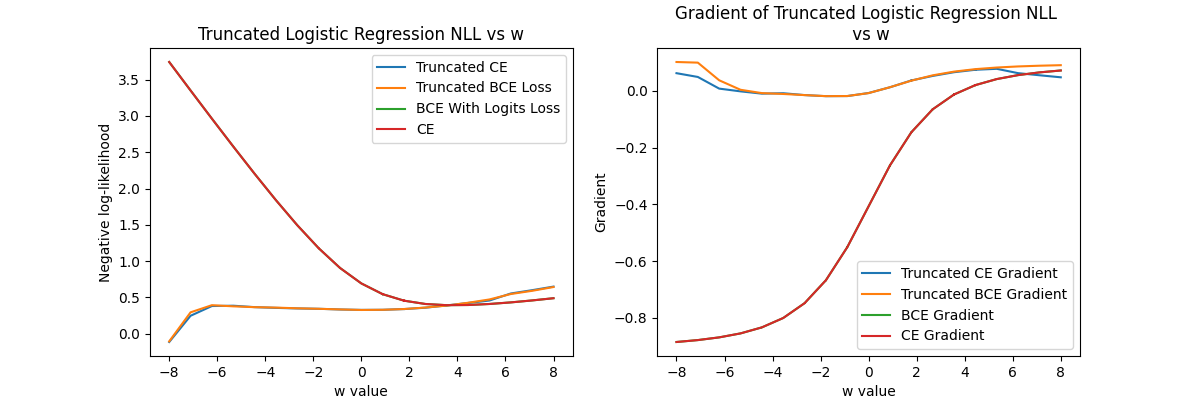

In [21]:
WS_ = ch.Tensor([])

for w_ in ws: 
    for w__ in ws: 
        WS_ = ch.cat([WS_, ch.cat([w_[...,None], w__[...,None]])[None,...]])

w_diffs = WS_[:,1] - WS_[:,0]

w_sorted, indices = w_diffs.sort()

# === Plot the loss landscape ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(w_sorted, losses[indices], label="Truncated CE")
ax1.plot(w_sorted, trunc_bce_losses[indices], label="Truncated BCE Loss")
ax1.plot(w_sorted, bce_losses[indices], label="BCE With Logits Loss")
ax1.plot(w_sorted, ce_losses[indices], label="CE")

ax1.set_xlabel("w value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Logistic Regression NLL vs w")
ax1.legend()

ax2.plot(w_sorted, grads[:,1][indices] - grads[:,0][indices], label="Truncated CE Gradient")
ax2.plot(w_sorted, trunc_bce_grads[:,1][indices] - trunc_bce_grads[:,0][indices], label="Truncated BCE Gradient")
ax2.plot(w_sorted, bce_grads[:,1][indices] - bce_grads[:,0][indices], label="BCE Gradient")
ax2.plot(w_sorted, ce_grads[:,1][indices] - ce_grads[:,0][indices], label="CE Gradient")


ax2.set_xlabel("w value")
ax2.set_ylabel("Gradient")
ax2.set_title("Gradient of Truncated Logistic Regression NLL \n vs w")
ax2.legend()

plt.show()

In [22]:
from torch.distributions import Uniform

d, k = 1, 2
# ground-truth logistic regression model 
w = Uniform(-1, 1)
U = Uniform(-5, 5)
W = w.sample([k, d])
print(f'ground truth: {W}')
print(f'effective ground truth: {W[1] - W[0]}')

# input features
SAMPLES = 1000
X = U.sample([SAMPLES, d])
# latent variables
z = X@W.T + gumbel.sample([X.size(0), k])
# classification
y = z.argmax(-1)

ground truth: tensor([[-0.2255],
        [-0.9466]])
effective ground truth: tensor([-0.7211])


In [23]:
from sklearn.metrics import confusion_matrix

sklearn = LogisticRegression(penalty=None, verbose=10, fit_intercept=False)
sklearn.fit(X, y.flatten())
sklearn_ = ch.from_numpy(sklearn.coef_)

print(f'sklearn: {sklearn_}')
pred = sklearn.predict(X)
acc = np.equal(pred, y.flatten()).sum() / len(y)
print(f'sklearn acc: {acc}')
sklearn_conf_matrix = confusion_matrix(y, pred)
print(f'sklearn confusion matrix: \n {sklearn_conf_matrix}')

sklearn: tensor([[-0.8118]], dtype=torch.float64)
sklearn acc: 0.8349999785423279
sklearn confusion matrix: 
 [[424  88]
 [ 77 411]]


[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
/tmp/ipykernel_34673/3637359842.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  acc = np.equal(pred, y.flatten()).sum() / len(y)


In [24]:
logits = X@sklearn_.float()
z = logits + logistic.sample(logits.size())
y = (z > 0).float()

In [25]:
X_trunc, Y_trunc = X, y
alpha = X_trunc.size(0) / X.size(0)
print(f'alpha: {alpha}')

alpha: 1.0


In [50]:
from delphi.stats.truncated_logistic_regression import TruncatedLogisticRegression
from delphi.utils.helpers import Parameters

def phi(z): 
    z_diff = (z[...,0] - z[...,1])[...,None]
    return ch.ones_like(z_diff)

emp_weight = ch.randn(W.size())
args = Parameters({
                    'batch_size': 100,
                    'epochs': 10,
                    'trials': 1,
                    'verbose': True,
                    'early_stopping': True,
                    'num_samples': 5000,
                    'shuffle': False
                })        
delphi_log_reg = TruncatedLogisticRegression(args,
                                            phi, 
                                            alpha, 
                                            fit_intercept=False,
                                            multi_class="multinomial", 
                                            emp_weight=emp_weight)
delphi_log_reg.fit(X_trunc, Y_trunc)

trial: 1
Creating SGD optimizer: {'lr': 0.1, 'momentum': 0.0, 'dampening': 0.0, 'weight_decay': 0.0, 'nesterov': False, 'maximize': False, 'differentiable': False}
Epoch 1 - Loss: 0.44838187098503113
Epoch 2 - Loss: 0.4284078776836395
Epoch 3 - Loss: 0.41961607336997986
Epoch 4 - Loss: 0.41534850001335144
Epoch 5 - Loss: 0.41260087490081787
Epoch 6 - Loss: 0.4139331877231598
Epoch 7 - Loss: 0.41197115182876587
Epoch 8 - Loss: 0.4139974117279053
Epoch 9 - Loss: 0.4143882989883423
Epoch 10 - Loss: 0.4140416085720062
Procedure did not converge after 10 epochs in 2.57 seconds


TruncatedLogisticRegression()

In [53]:
delphi_log_reg.predict(X)[...,None]

tensor([[0],
        [1],
        [1],
        [1],
        [1],
        [0],
        [1],
        [1],
        [1],
        [0],
        [0],
        [0],
        [1],
        [0],
        [1],
        [0],
        [0],
        [1],
        [0],
        [1],
        [0],
        [1],
        [1],
        [0],
        [1],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0],
        [0],
        [1],
        [0],
        [1],
        [1],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0],
        [1],
        [1],
        [1],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [0],
        [0],
        [0],
        [0],
        [1],
        [1],
        [1],
        [1],
        [0],
        [0],
        [0],
        [1],
        [0],
        [1],
        [1],

In [54]:
from torch.nn import CosineSimilarity
cos_sim = CosineSimilarity()

delphi_log_reg_ = delphi_log_reg.coef_                
print(f'delphi log reg: {delphi_log_reg_}')
delphi_diff_ = delphi_log_reg_[1] - delphi_log_reg_[0]
delphi_cos_sim = float(cos_sim(delphi_diff_[None,...], sklearn_))
delphi_pred = delphi_log_reg.predict(X)[...,None]
delphi_acc = delphi_pred.eq(y).sum() / len(y)
print(f'delphi accuracy: {delphi_acc}')
print(f'delphi cos sim: {delphi_cos_sim}')
delphi_conf_matrix = confusion_matrix(y, delphi_pred)
print(f'delphi confusion matrix: \n {delphi_conf_matrix}')

delphi log reg: tensor([[1.0351],
        [0.2175]])
delphi accuracy: 0.8420000076293945
delphi cos sim: 1.0
delphi confusion matrix: 
 [[420  77]
 [ 81 422]]


In [55]:
def gumbel_wrapper(pred, targ, loss_fn=TruncatedCE_contained): 
    print(f"gumbel wrapper pred: {pred}")
    return trunc_gumbel_mle(pred, targ, phi, loss_fn=loss_fn)[0].detach().item()

In [56]:
X_train, Y_train = delphi_log_reg.train_loader.dataset.tensors

In [57]:
WS_ = delphi_log_reg.trainer.train_param_history
WS_.requires_grad = True

rand_perm = ch.randperm(X_train.size(0))[:args.batch_size]


losses_contained = ch.Tensor([gumbel_wrapper(X_train[rand_perm]@ws_[None,...], Y_train[rand_perm]) for ws_  in WS_])
print("=====TruncatedCE=====")
losses = ch.Tensor([gumbel_wrapper(X_train[rand_perm]@ws_[None,...], Y_train[rand_perm], loss_fn=TruncatedCE) for ws_  in WS_])

gumbel wrapper pred: tensor([[-2.2387e+00,  1.2174e-01],
        [ 6.2122e+00, -3.3783e-01],
        [-3.9100e+00,  2.1264e-01],
        [ 8.0587e-01, -4.3826e-02],
        [-5.4005e-01,  2.9369e-02],
        [ 1.0870e+00, -5.9117e-02],
        [ 3.0550e+00, -1.6614e-01],
        [-5.0683e+00,  2.7563e-01],
        [-5.7026e-01,  3.1012e-02],
        [-3.4781e+00,  1.8915e-01],
        [-5.8135e+00,  3.1616e-01],
        [ 6.1958e+00, -3.3694e-01],
        [ 3.2103e+00, -1.7459e-01],
        [ 5.6412e+00, -3.0678e-01],
        [-6.8282e-01,  3.7133e-02],
        [-1.4862e+00,  8.0823e-02],
        [ 4.4312e+00, -2.4098e-01],
        [ 2.1936e+00, -1.1929e-01],
        [-2.6771e-02,  1.4559e-03],
        [ 6.2258e+00, -3.3858e-01],
        [-5.4171e+00,  2.9460e-01],
        [-5.6662e+00,  3.0815e-01],
        [-3.0741e+00,  1.6718e-01],
        [-5.2930e+00,  2.8785e-01],
        [-1.5026e+00,  8.1713e-02],
        [-3.2830e+00,  1.7854e-01],
        [-2.8000e+00,  1.5227e-01],
       

/tmp/ipykernel_34673/2544813244.py:15: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  return loss, pred.grad


gumbel wrapper pred: tensor([[-2.0377e+00, -7.9716e-02],
        [ 5.6546e+00,  2.2121e-01],
        [-3.5591e+00, -1.3923e-01],
        [ 7.3355e-01,  2.8696e-02],
        [-4.9158e-01, -1.9231e-02],
        [ 9.8949e-01,  3.8709e-02],
        [ 2.7809e+00,  1.0879e-01],
        [-4.6135e+00, -1.8048e-01],
        [-5.1908e-01, -2.0306e-02],
        [-3.1659e+00, -1.2385e-01],
        [-5.2918e+00, -2.0701e-01],
        [ 5.6397e+00,  2.2063e-01],
        [ 2.9222e+00,  1.1432e-01],
        [ 5.1349e+00,  2.0088e-01],
        [-6.2154e-01, -2.4314e-02],
        [-1.3528e+00, -5.2922e-02],
        [ 4.0336e+00,  1.5779e-01],
        [ 1.9967e+00,  7.8112e-02],
        [-2.4368e-02, -9.5328e-04],
        [ 5.6671e+00,  2.2170e-01],
        [-4.9309e+00, -1.9290e-01],
        [-5.1577e+00, -2.0177e-01],
        [-2.7982e+00, -1.0947e-01],
        [-4.8180e+00, -1.8848e-01],
        [-1.3677e+00, -5.3504e-02],
        [-2.9884e+00, -1.1691e-01],
        [-2.5487e+00, -9.9705e-02],
       

gumbel wrapper pred: tensor([[-1.7950e+00, -3.2672e-01],
        [ 4.9811e+00,  9.0663e-01],
        [-3.1352e+00, -5.7064e-01],
        [ 6.4618e-01,  1.1761e-01],
        [-4.3303e-01, -7.8817e-02],
        [ 8.7163e-01,  1.5865e-01],
        [ 2.4496e+00,  4.4587e-01],
        [-4.0640e+00, -7.3969e-01],
        [-4.5726e-01, -8.3226e-02],
        [-2.7889e+00, -5.0761e-01],
        [-4.6615e+00, -8.4846e-01],
        [ 4.9680e+00,  9.0424e-01],
        [ 2.5742e+00,  4.6853e-01],
        [ 4.5233e+00,  8.2330e-01],
        [-5.4751e-01, -9.9654e-02],
        [-1.1917e+00, -2.1690e-01],
        [ 3.5531e+00,  6.4672e-01],
        [ 1.7589e+00,  3.2015e-01],
        [-2.1466e-02, -3.9070e-03],
        [ 4.9921e+00,  9.0863e-01],
        [-4.3436e+00, -7.9059e-01],
        [-4.5434e+00, -8.2696e-01],
        [-2.4649e+00, -4.4865e-01],
        [-4.2441e+00, -7.7249e-01],
        [-1.2048e+00, -2.1929e-01],
        [-2.6325e+00, -4.7914e-01],
        [-2.2451e+00, -4.0864e-01],
       

gumbel wrapper pred: tensor([[-1.7477e+00, -3.7555e-01],
        [ 4.8497e+00,  1.0421e+00],
        [-3.0525e+00, -6.5594e-01],
        [ 6.2913e-01,  1.3519e-01],
        [-4.2160e-01, -9.0597e-02],
        [ 8.4864e-01,  1.8236e-01],
        [ 2.3850e+00,  5.1251e-01],
        [-3.9567e+00, -8.5025e-01],
        [-4.4519e-01, -9.5666e-02],
        [-2.7153e+00, -5.8348e-01],
        [-4.5385e+00, -9.7527e-01],
        [ 4.8369e+00,  1.0394e+00],
        [ 2.5062e+00,  5.3856e-01],
        [ 4.4040e+00,  9.4636e-01],
        [-5.3306e-01, -1.1455e-01],
        [-1.1602e+00, -2.4932e-01],
        [ 3.4594e+00,  7.4338e-01],
        [ 1.7125e+00,  3.6800e-01],
        [-2.0899e-02, -4.4910e-03],
        [ 4.8604e+00,  1.0444e+00],
        [-4.2290e+00, -9.0876e-01],
        [-4.4235e+00, -9.5056e-01],
        [-2.3999e+00, -5.1571e-01],
        [-4.1322e+00, -8.8795e-01],
        [-1.1730e+00, -2.5207e-01],
        [-2.5630e+00, -5.5076e-01],
        [-2.1859e+00, -4.6972e-01],
       

gumbel wrapper pred: tensor([[-2.1734e+00,  5.6873e-02],
        [ 6.0310e+00, -1.5782e-01],
        [-3.7960e+00,  9.9333e-02],
        [ 7.8238e-01, -2.0473e-02],
        [-5.2430e-01,  1.3720e-02],
        [ 1.0554e+00, -2.7616e-02],
        [ 2.9660e+00, -7.7613e-02],
        [-4.9205e+00,  1.2876e-01],
        [-5.5363e-01,  1.4487e-02],
        [-3.3767e+00,  8.8360e-02],
        [-5.6440e+00,  1.4769e-01],
        [ 6.0151e+00, -1.5740e-01],
        [ 3.1167e+00, -8.1558e-02],
        [ 5.4767e+00, -1.4331e-01],
        [-6.6291e-01,  1.7347e-02],
        [-1.4429e+00,  3.7756e-02],
        [ 4.3020e+00, -1.1258e-01],
        [ 2.1296e+00, -5.5728e-02],
        [-2.5990e-02,  6.8010e-04],
        [ 6.0443e+00, -1.5817e-01],
        [-5.2591e+00,  1.3762e-01],
        [-5.5010e+00,  1.4395e-01],
        [-2.9845e+00,  7.8098e-02],
        [-5.1387e+00,  1.3447e-01],
        [-1.4587e+00,  3.8172e-02],
        [-3.1873e+00,  8.3405e-02],
        [-2.7183e+00,  7.1133e-02],
       

gumbel wrapper pred: tensor([[-1.8531e+00, -2.6441e-01],
        [ 5.1423e+00,  7.3373e-01],
        [-3.2366e+00, -4.6182e-01],
        [ 6.6709e-01,  9.5184e-02],
        [-4.4704e-01, -6.3786e-02],
        [ 8.9983e-01,  1.2839e-01],
        [ 2.5289e+00,  3.6084e-01],
        [-4.1954e+00, -5.9863e-01],
        [-4.7205e-01, -6.7355e-02],
        [-2.8791e+00, -4.1080e-01],
        [-4.8123e+00, -6.8665e-01],
        [ 5.1287e+00,  7.3180e-01],
        [ 2.6574e+00,  3.7918e-01],
        [ 4.6697e+00,  6.6629e-01],
        [-5.6522e-01, -8.0649e-02],
        [-1.2302e+00, -1.7554e-01],
        [ 3.6681e+00,  5.2338e-01],
        [ 1.8158e+00,  2.5909e-01],
        [-2.2160e-02, -3.1619e-03],
        [ 5.1536e+00,  7.3535e-01],
        [-4.4841e+00, -6.3982e-01],
        [-4.6904e+00, -6.6925e-01],
        [-2.5447e+00, -3.6309e-01],
        [-4.3815e+00, -6.2517e-01],
        [-1.2438e+00, -1.7747e-01],
        [-2.7176e+00, -3.8777e-01],
        [-2.3178e+00, -3.3071e-01],
       

gumbel wrapper pred: tensor([[-1.7567e+00, -3.5995e-01],
        [ 4.8748e+00,  9.9884e-01],
        [-3.0682e+00, -6.2868e-01],
        [ 6.3238e-01,  1.2957e-01],
        [-4.2378e-01, -8.6833e-02],
        [ 8.5302e-01,  1.7478e-01],
        [ 2.3973e+00,  4.9121e-01],
        [-3.9772e+00, -8.1492e-01],
        [-4.4749e-01, -9.1691e-02],
        [-2.7293e+00, -5.5923e-01],
        [-4.5620e+00, -9.3474e-01],
        [ 4.8619e+00,  9.9620e-01],
        [ 2.5192e+00,  5.1618e-01],
        [ 4.4267e+00,  9.0703e-01],
        [-5.3582e-01, -1.0979e-01],
        [-1.1662e+00, -2.3896e-01],
        [ 3.4773e+00,  7.1249e-01],
        [ 1.7214e+00,  3.5270e-01],
        [-2.1007e-02, -4.3044e-03],
        [ 4.8855e+00,  1.0010e+00],
        [-4.2509e+00, -8.7100e-01],
        [-4.4464e+00, -9.1106e-01],
        [-2.4123e+00, -4.9428e-01],
        [-4.1535e+00, -8.5105e-01],
        [-1.1791e+00, -2.4159e-01],
        [-2.5763e+00, -5.2787e-01],
        [-2.1972e+00, -4.5020e-01],
       

gumbel wrapper pred: tensor([[-1.7528e+00, -3.7281e-01],
        [ 4.8640e+00,  1.0345e+00],
        [-3.0615e+00, -6.5114e-01],
        [ 6.3099e-01,  1.3420e-01],
        [-4.2285e-01, -8.9935e-02],
        [ 8.5114e-01,  1.8103e-01],
        [ 2.3920e+00,  5.0876e-01],
        [-3.9684e+00, -8.4404e-01],
        [-4.4650e-01, -9.4967e-02],
        [-2.7233e+00, -5.7921e-01],
        [-4.5519e+00, -9.6814e-01],
        [ 4.8512e+00,  1.0318e+00],
        [ 2.5136e+00,  5.3462e-01],
        [ 4.4170e+00,  9.3944e-01],
        [-5.3463e-01, -1.1371e-01],
        [-1.1637e+00, -2.4750e-01],
        [ 3.4696e+00,  7.3795e-01],
        [ 1.7176e+00,  3.6531e-01],
        [-2.0961e-02, -4.4582e-03],
        [ 4.8747e+00,  1.0368e+00],
        [-4.2415e+00, -9.0212e-01],
        [-4.4366e+00, -9.4362e-01],
        [-2.4070e+00, -5.1194e-01],
        [-4.1443e+00, -8.8146e-01],
        [-1.1765e+00, -2.5022e-01],
        [-2.5706e+00, -5.4673e-01],
        [-2.1923e+00, -4.6629e-01],
       

In [58]:
w_diffs = (WS_[:,1] - WS_[:,0]).detach()
w_sorted, indices = w_diffs.sort()

<IPython.core.display.Javascript object>


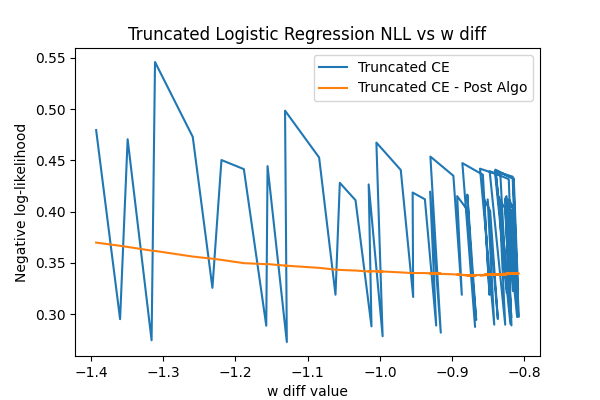

In [59]:
fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))

ax1.plot(w_diffs.detach(), delphi_log_reg.trainer.train_losses, label="Truncated CE")
ax1.plot(w_diffs.detach(), losses, label="Truncated CE - Post Algo")

ax1.set_xlabel("w diff value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Logistic Regression NLL vs w diff")
ax1.legend()


plt.show()

# Truncated Logistic Regression OVR

In [60]:
from delphi.stats.truncated_logistic_regression import TruncatedLogisticRegression
from delphi.utils.helpers import Parameters

def phi(z): 
    return ch.ones_like(z)

emp_weight = ch.randn(1, 1)
args = Parameters({
                    'batch_size': 100,
                    'epochs': 10,
                    'trials': 1,
                    'verbose': True,
                    'early_stopping': True,
                    'num_samples': 5000,
                    'shuffle': False
                })        
delphi_log_reg = TruncatedLogisticRegression(args,
                                            phi, 
                                            alpha, 
                                            fit_intercept=False,
                                            multi_class="ovr", 
                                            emp_weight=emp_weight)
delphi_log_reg.fit(X_trunc, Y_trunc)

trial: 1
Creating SGD optimizer: {'lr': 0.1, 'momentum': 0.0, 'dampening': 0.0, 'weight_decay': 0.0, 'nesterov': False, 'maximize': False, 'differentiable': False}
Epoch 1 - Loss: 0.41898611187934875
Epoch 2 - Loss: 0.4173242151737213
Epoch 3 - Loss: 0.4132620096206665
Epoch 4 - Loss: 0.415784627199173
Epoch 5 - Loss: 0.41344642639160156
Epoch 6 - Loss: 0.4146720767021179
Epoch 7 - Loss: 0.4139476418495178
Epoch 8 - Loss: 0.4140993654727936
Epoch 9 - Loss: 0.41157805919647217
Epoch 10 - Loss: 0.41145196557044983
Procedure did not converge after 10 epochs in 1.48 seconds


TruncatedLogisticRegression()

In [61]:
from torch.nn import CosineSimilarity
cos_sim = CosineSimilarity()

delphi_log_reg_ = delphi_log_reg.coef_                
print(f'delphi log reg: {delphi_log_reg_}')
delphi_cos_sim = float(cos_sim(delphi_log_reg_[None,...], sklearn_))
delphi_pred = delphi_log_reg.predict(X)
delphi_acc = delphi_pred.eq(y).sum() / len(y)
print(f'delphi accuracy: {delphi_acc}')
print(f'delphi cos sim: {delphi_cos_sim}')
delphi_conf_matrix = confusion_matrix(y, delphi_pred)
print(f'delphi confusion matrix: \n {delphi_conf_matrix}')

delphi log reg: tensor([[-0.8176]])
delphi accuracy: 0.8420000076293945
delphi cos sim: 1.0
delphi confusion matrix: 
 [[420  77]
 [ 81 422]]


<IPython.core.display.Javascript object>


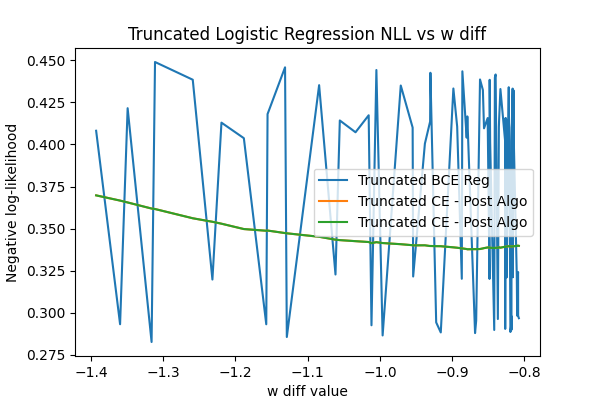

In [62]:
fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))

ax1.plot(w_sorted.detach(), delphi_log_reg.trainer.train_losses[indices], label="Truncated BCE Reg")
ax1.plot(w_sorted.detach(), losses[indices], label="Truncated CE - Post Algo")
ax1.plot(w_sorted.detach(), losses_contained[indices], label="Truncated CE - Post Algo")

ax1.set_xlabel("w diff value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Logistic Regression NLL vs w diff")
ax1.legend()


plt.show()

# Softmax Regression

In [63]:
def phi(z): 
    z_diff = (z[...,0] - z[...,1])[...,None]
    return ch.ones_like(z_diff)

emp_weight = ch.randn(W.size())
args = Parameters({
                    'batch_size': 1000,
                    'epochs': 10,
                    'trials': 1,
                    'verbose': True,
                    'early_stopping': True,
                    'num_samples': 1000,
                    'shuffle': False
                })        
delphi_soft_reg = SoftmaxRegression(args,
                                    fit_intercept=False)
delphi_soft_reg.fit(X_trunc, Y_trunc.long())

trial: 1
Creating SGD optimizer: {'lr': 0.1, 'momentum': 0.0, 'dampening': 0.0, 'weight_decay': 0.0, 'nesterov': False, 'maximize': False, 'differentiable': False}
Epoch 1 - Loss: 0.562458336353302
Epoch 2 - Loss: 0.5554384589195251
Epoch 3 - Loss: 0.5485658645629883
Epoch 4 - Loss: 0.5418456792831421
Epoch 5 - Loss: 0.535282552242279
Epoch 6 - Loss: 0.5288816094398499
Epoch 7 - Loss: 0.5226477980613708
Epoch 8 - Loss: 0.5165855288505554
Epoch 9 - Loss: 0.5106998682022095
Epoch 10 - Loss: 0.5049947500228882
Procedure did not converge after 10 epochs in 2.25 seconds


SoftmaxRegression(
  (criterion): CrossEntropyLoss()
)

In [64]:
from torch.nn import CosineSimilarity
cos_sim = CosineSimilarity()

delphi_soft_reg_ = delphi_soft_reg.coef_                
print(f'delphi soft reg: {delphi_soft_reg_}')
delphi_diff_ = delphi_soft_reg_[1] - delphi_soft_reg_[0]
delphi_cos_sim = float(cos_sim(delphi_diff_[None,...], sklearn_))
delphi_pred = delphi_soft_reg.predict(X)
delphi_acc = delphi_pred.eq(y).sum() / len(y)
print(f'delphi accuracy: {delphi_acc}')
print(f'delphi cos sim: {delphi_cos_sim}')
delphi_conf_matrix = confusion_matrix(y, delphi_pred)
print(f'delphi confusion matrix: \n {delphi_conf_matrix}')

delphi soft reg: tensor([[ 1.3800],
        [-0.1324]])
delphi accuracy: 499.9939880371094
delphi cos sim: 1.0
delphi confusion matrix: 
 [[420  77]
 [ 81 422]]


In [65]:
WS_ = delphi_soft_reg.trainer.train_param_history
WS_.requires_grad = True
rand_perm = ch.randperm(X_train.size(0))[:args.batch_size]

losses_contained = ch.Tensor([gumbel_wrapper(X_train[rand_perm]@ws_[None,...], Y_train[rand_perm]) for ws_  in WS_])
print("=====TruncatedCE=====")
losses = ch.Tensor([gumbel_wrapper(X_train[rand_perm]@ws_[None,...], Y_train[rand_perm], loss_fn=TruncatedCE) for ws_  in WS_])

gumbel wrapper pred: tensor([[-2.4463,  0.4658],
        [-5.1444,  0.9796],
        [ 2.8542, -0.5435],
        ...,
        [-1.8319,  0.3488],
        [-6.1926,  1.1792],
        [ 1.8930, -0.3605]], grad_fn=<MmBackward0>)
gumbel wrapper pred: tensor([[-2.4193,  0.4388],
        [-5.0876,  0.9227],
        [ 2.8227, -0.5119],
        ...,
        [-1.8117,  0.3286],
        [-6.1241,  1.1107],
        [ 1.8721, -0.3395]], grad_fn=<MmBackward0>)
gumbel wrapper pred: tensor([[-2.3926,  0.4120],
        [-5.0314,  0.8665],
        [ 2.7915, -0.4807],
        ...,
        [-1.7916,  0.3086],
        [-6.0564,  1.0430],
        [ 1.8514, -0.3188]], grad_fn=<MmBackward0>)
gumbel wrapper pred: tensor([[-2.3661,  0.3856],
        [-4.9758,  0.8109],
        [ 2.7606, -0.4499],
        ...,
        [-1.7718,  0.2888],
        [-5.9895,  0.9761],
        [ 1.8309, -0.2984]], grad_fn=<MmBackward0>)
gumbel wrapper pred: tensor([[-2.3400,  0.3595],
        [-4.9208,  0.7560],
        [ 2.7302, -

/tmp/ipykernel_34673/2544813244.py:15: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:489.)
  return loss, pred.grad


gumbel wrapper pred: tensor([[-2.3142,  0.3337],
        [-4.8666,  0.7017],
        [ 2.7001, -0.3893],
        ...,
        [-1.7330,  0.2499],
        [-5.8581,  0.8447],
        [ 1.7908, -0.2582]], grad_fn=<MmBackward0>)
gumbel wrapper pred: tensor([[-2.2888,  0.3083],
        [-4.8131,  0.6482],
        [ 2.6704, -0.3597],
        ...,
        [-1.7139,  0.2308],
        [-5.7937,  0.7803],
        [ 1.7711, -0.2385]], grad_fn=<MmBackward0>)
gumbel wrapper pred: tensor([[-2.2637,  0.2832],
        [-4.7604,  0.5955],
        [ 2.6411, -0.3304],
        ...,
        [-1.6951,  0.2121],
        [-5.7302,  0.7168],
        [ 1.7517, -0.2191]], grad_fn=<MmBackward0>)
gumbel wrapper pred: tensor([[-2.2390,  0.2585],
        [-4.7084,  0.5435],
        [ 2.6123, -0.3016],
        ...,
        [-1.6766,  0.1936],
        [-5.6677,  0.6543],
        [ 1.7325, -0.2000]], grad_fn=<MmBackward0>)
gumbel wrapper pred: tensor([[-2.2147,  0.2342],
        [-4.6573,  0.4924],
        [ 2.5840, -

In [66]:
w_diffs = (WS_[:,1] - WS_[:,0]).detach()
w_sorted, indices = w_diffs.sort()

<IPython.core.display.Javascript object>


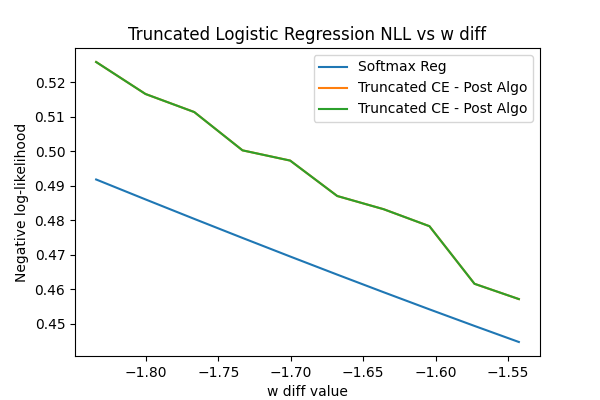

In [67]:
fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))

ax1.plot(w_sorted.detach(), delphi_soft_reg.trainer.train_losses[indices], label="Softmax Reg")
ax1.plot(w_sorted.detach(), losses[indices], label="Truncated CE - Post Algo")
ax1.plot(w_sorted.detach(), losses_contained[indices], label="Truncated CE - Post Algo")

ax1.set_xlabel("w diff value")
ax1.set_ylabel("Negative log-likelihood")
ax1.set_title("Truncated Logistic Regression NLL vs w diff")
ax1.legend()


plt.show()